# **Importing Libraries**

In [31]:
import pandas as pd
from pandas import DataFrame
import sklearn as sk
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
cd /content/drive/My Drive/Dataset

/content/drive/My Drive/Dataset


In [34]:
data_raw=pd.read_csv('cirrhosis.csv')

# **Understanding data**

In [ ]:
data_raw.shape

(418, 20)

In [35]:
pd.set_option('display.max_columns', None)

#data_raw.drop('ID', axis=1, inplace=True)
data_raw.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [ ]:
data_raw.columns

Index(['ID', 'N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites',
       'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol',
       'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets',
       'Prothrombin', 'Stage'],
      dtype='object')

In [ ]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [ ]:
data_raw.describe()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [36]:
data_raw['Age'] = (data_raw['Age']/365).astype('int64') # convert age to years


In [ ]:
data_raw.head(20)

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,58,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,56,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,70,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,54,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,38,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
5,6,2503,D,Placebo,66,F,N,Y,N,N,0.8,248.0,3.98,50.0,944.0,93.00,63.0,NaN,11.0,3.0
6,7,1832,C,Placebo,55,F,N,Y,N,N,1.0,322.0,4.09,52.0,824.0,60.45,213.0,204.0,9.7,3.0
7,8,2466,D,Placebo,53,F,N,N,N,N,0.3,280.0,4.00,52.0,4651.2,28.38,189.0,373.0,11.0,3.0
8,9,2400,D,D-penicillamine,42,F,N,N,Y,N,3.2,562.0,3.08,79.0,2276.0,144.15,88.0,251.0,11.0,2.0
9,10,51,D,Placebo,70,F,Y,N,Y,Y,12.6,200.0,2.74,140.0,918.0,147.25,143.0,302.0,11.5,4.0


# **Outlier Detection**

In [37]:
def plot_boxplot(data, ft):
  data.boxplot(column=[ft])
  plt.grid(False)
  plt.show()

<Axes: >

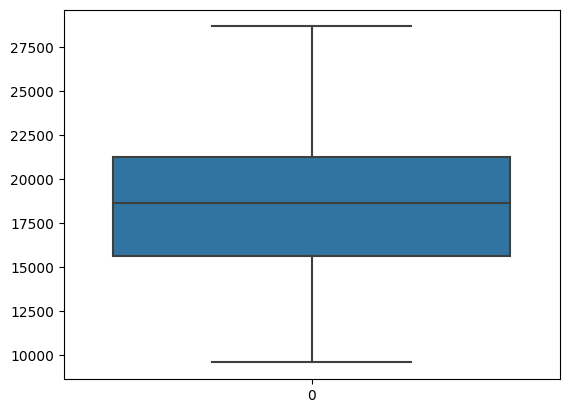

In [ ]:
sns.boxplot(data_raw["Age"])

In [ ]:
plot_boxplot(data_raw,"Age")

In [ ]:
plot_boxplot(data_raw,"Bilirubin")

In [ ]:
plot_boxplot(data_raw,"Cholesterol")

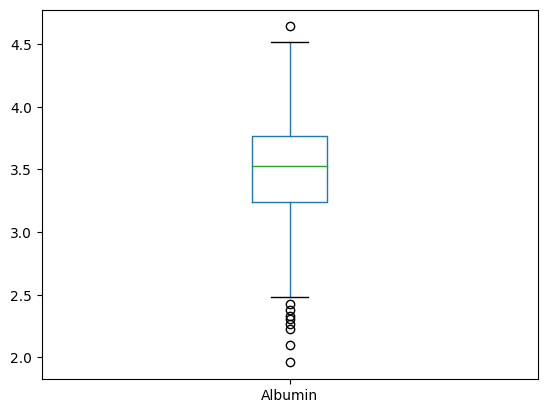

In [ ]:
plot_boxplot(data_raw,"Albumin")

In [38]:
numeric_data_raw = data_raw.select_dtypes(include=np.number)

Q1 = numeric_data_raw.quantile(0.25)
Q3 = numeric_data_raw.quantile(0.75)
IQR = Q3 - Q1
Lower_Fence = Q1 - 1.5 * IQR
Upper_Fence = Q3 + 1.5 * IQR

print(Lower_Fence)

ID               -207.50000
N_Days          -1188.37500
Age                18.00000
Bilirubin          -3.10000
Cholesterol        23.75000
Albumin             2.45125
Copper            -81.37500
Alk_Phos         -791.25000
SGOT              -26.35000
Tryglicerides     -15.87500
Platelets          -5.75000
Prothrombin         8.35000
Stage              -1.00000
dtype: float64


In [39]:
data_raw.drop(data_raw[(data_raw.Albumin < Lower_Fence.Albumin) |(data_raw.Albumin > Upper_Fence.Albumin)].index,inplace=True)

<Axes: >

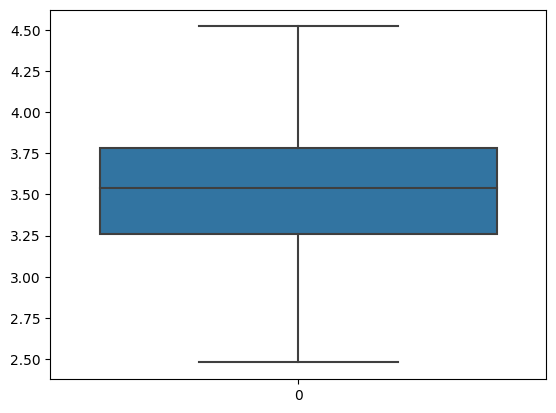

In [ ]:
sns.boxplot(data_raw["Albumin"])

In [ ]:
data_raw.shape

(409, 20)

In [ ]:
plot_boxplot(data_raw,"Copper")

In [ ]:
plot_boxplot(data_raw,"Alk_Phos")

In [ ]:
plot_boxplot(data_raw,"SGOT")

In [ ]:
plot_boxplot(data_raw,"Tryglicerides")

In [ ]:
plot_boxplot(data_raw,"Platelets")

In [ ]:
plot_boxplot(data_raw,"Prothrombin")

In [ ]:
plot_boxplot(data_raw,"Stage")

In [40]:
data_cleaned = data_raw

In [ ]:
data_cleaned.head(20)

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,58,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,56,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,70,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,54,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,38,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
5,6,2503,D,Placebo,66,F,N,Y,N,N,0.8,248.0,3.98,50.0,944.0,93.00,63.0,NaN,11.0,3.0
6,7,1832,C,Placebo,55,F,N,Y,N,N,1.0,322.0,4.09,52.0,824.0,60.45,213.0,204.0,9.7,3.0
7,8,2466,D,Placebo,53,F,N,N,N,N,0.3,280.0,4.00,52.0,4651.2,28.38,189.0,373.0,11.0,3.0
8,9,2400,D,D-penicillamine,42,F,N,N,Y,N,3.2,562.0,3.08,79.0,2276.0,144.15,88.0,251.0,11.0,2.0
9,10,51,D,Placebo,70,F,Y,N,Y,Y,12.6,200.0,2.74,140.0,918.0,147.25,143.0,302.0,11.5,4.0


In [ ]:
data_cleaned.shape

(409, 20)

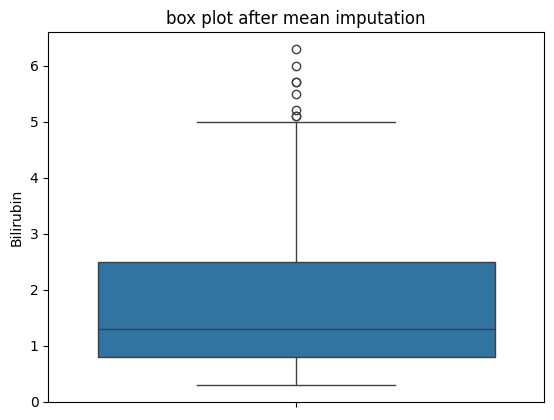

In [41]:

for i in data_cleaned['Bilirubin']:
  q1 = data_cleaned['Bilirubin'].quantile(0.25)
  q3 = data_cleaned['Bilirubin'].quantile(0.75)
  iqr = q3-q1
  Lower_tail = q1 - 1.5 * iqr
  Upper_tail = q3 + 1.5 * iqr
  if i > Upper_tail or i < Lower_tail:
      data_cleaned['Bilirubin'] = data_cleaned['Bilirubin'].replace(i, np.mean(data_cleaned['Bilirubin']))
sns.boxplot(data_cleaned['Bilirubin'])
plt.title("box plot after mean imputation")
plt.show()

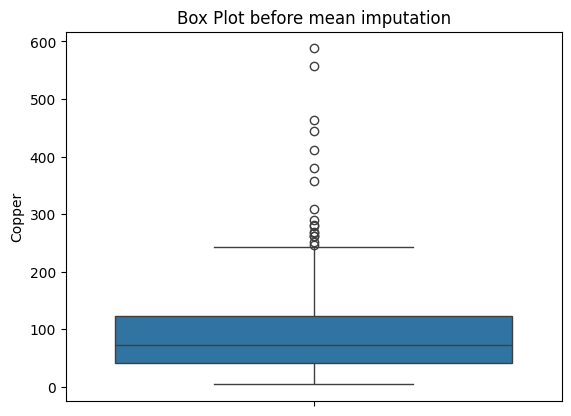

In [ ]:
sns.boxplot(data_cleaned['Copper'])
plt.title("Box Plot before mean imputation")
plt.show()

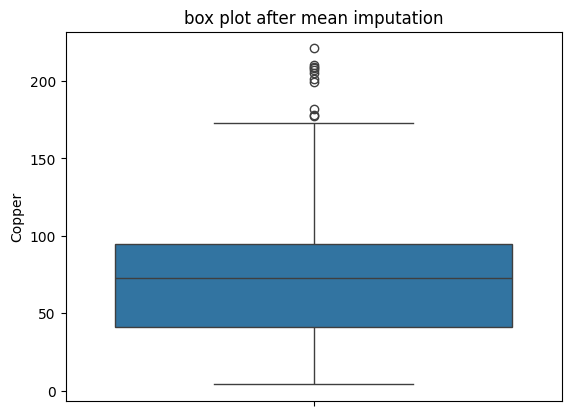

In [42]:
for i in data_cleaned['Copper']:
  q1 = data_cleaned['Copper'].quantile(0.25)
  q3 = data_cleaned['Copper'].quantile(0.75)
  iqr = q3-q1
  Lower_tail = q1 - 1.5 * iqr
  Upper_tail = q3 + 1.5 * iqr
  if i > Upper_tail or i < Lower_tail:
      data_cleaned['Copper'] = data_cleaned['Copper'].replace(i, np.mean(data_cleaned['Copper']))
sns.boxplot(data_cleaned['Copper'])
plt.title("box plot after mean imputation")
plt.show()

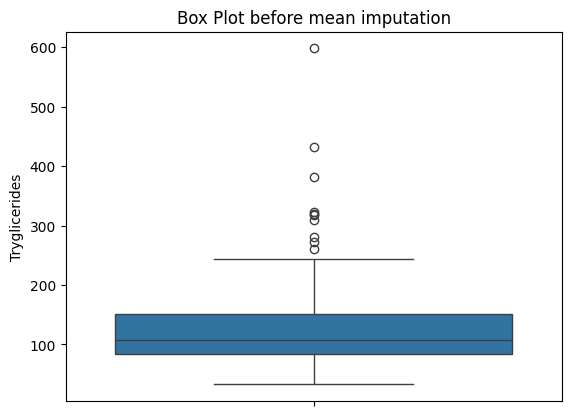

In [ ]:
sns.boxplot(data_cleaned['Tryglicerides'])
plt.title("Box Plot before mean imputation")
plt.show()

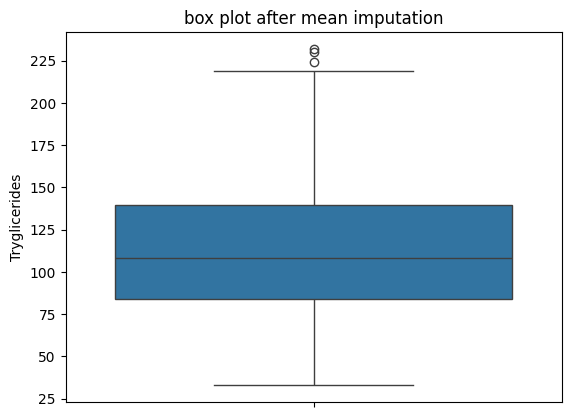

In [43]:
for i in data_cleaned['Tryglicerides']:
  q1 = data_cleaned['Tryglicerides'].quantile(0.25)
  q3 = data_cleaned['Tryglicerides'].quantile(0.75)
  iqr = q3-q1
  Lower_tail = q1 - 1.5 * iqr
  Upper_tail = q3 + 1.5 * iqr
  if i > Upper_tail or i < Lower_tail:
      data_cleaned['Tryglicerides'] = data_cleaned['Tryglicerides'].replace(i, np.mean(data_cleaned['Tryglicerides']))
sns.boxplot(data_cleaned['Tryglicerides'])
plt.title("box plot after mean imputation")
plt.show()

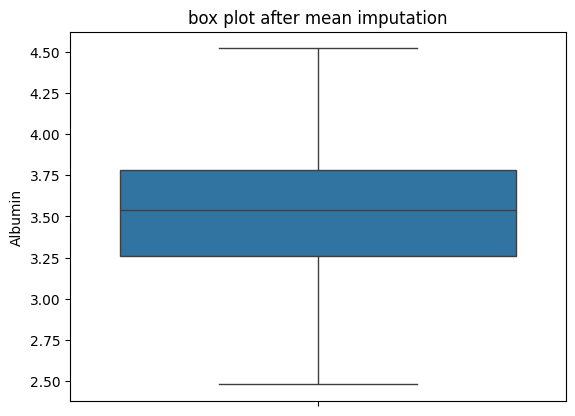

In [44]:
for i in data_cleaned['Albumin']:
  q1 = data_cleaned['Albumin'].quantile(0.25)
  q3 = data_cleaned['Albumin'].quantile(0.75)
  iqr = q3-q1
  Lower_tail = q1 - 1.5 * iqr
  Upper_tail = q3 + 1.5 * iqr
  if i > Upper_tail or i < Lower_tail:
      data_cleaned['Albumin'] = data_cleaned['Albumin'].replace(i, np.mean(data_cleaned['Albumin']))
sns.boxplot(data_cleaned['Albumin'])
plt.title("box plot after mean imputation")
plt.show()

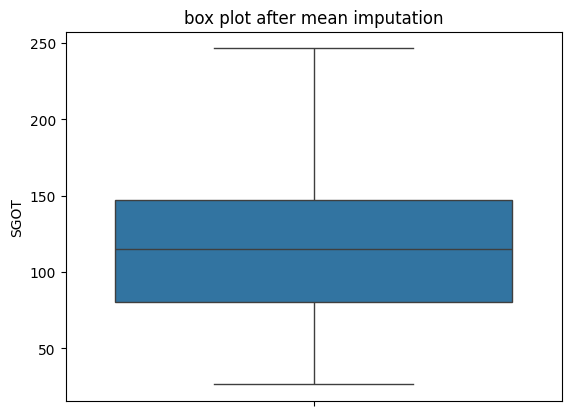

In [45]:
for i in data_cleaned['SGOT']:
  q1 = data_cleaned['SGOT'].quantile(0.25)
  q3 = data_cleaned['SGOT'].quantile(0.75)
  iqr = q3-q1
  Lower_tail = q1 - 1.5 * iqr
  Upper_tail = q3 + 1.5 * iqr
  if i > Upper_tail or i < Lower_tail:
      data_cleaned['SGOT'] = data_cleaned['SGOT'].replace(i, np.mean(data_cleaned['SGOT']))
sns.boxplot(data_cleaned['SGOT'])
plt.title("box plot after mean imputation")
plt.show()

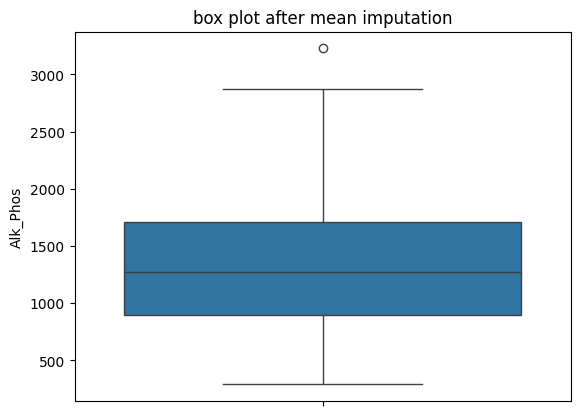

In [46]:
for i in data_cleaned['Alk_Phos']:
  q1 = data_cleaned['Alk_Phos'].quantile(0.25)
  q3 = data_cleaned['Alk_Phos'].quantile(0.75)
  iqr = q3-q1
  Lower_tail = q1 - 1.5 * iqr
  Upper_tail = q3 + 1.5 * iqr
  if i > Upper_tail or i < Lower_tail:
      data_cleaned['Alk_Phos'] = data_cleaned['Alk_Phos'].replace(i, np.mean(data_cleaned['Alk_Phos']))
sns.boxplot(data_cleaned['Alk_Phos'])
plt.title("box plot after mean imputation")
plt.show()

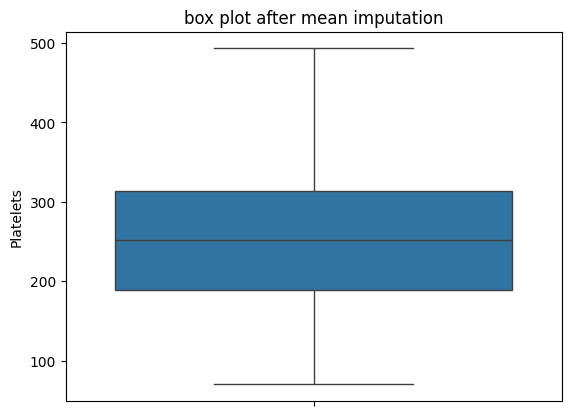

In [47]:
for i in data_cleaned['Platelets']:
  q1 = data_cleaned['Platelets'].quantile(0.25)
  q3 = data_cleaned['Platelets'].quantile(0.75)
  iqr = q3-q1
  Lower_tail = q1 - 1.5 * iqr
  Upper_tail = q3 + 1.5 * iqr
  if i > Upper_tail or i < Lower_tail:
      data_cleaned['Platelets'] = data_cleaned['Platelets'].replace(i, np.mean(data_cleaned['Platelets']))
sns.boxplot(data_cleaned['Platelets'])
plt.title("box plot after mean imputation")
plt.show()

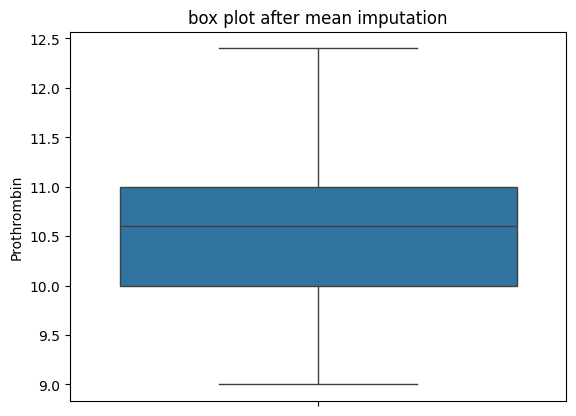

In [48]:
for i in data_cleaned['Prothrombin']:
  q1 = data_cleaned['Prothrombin'].quantile(0.25)
  q3 = data_cleaned['Prothrombin'].quantile(0.75)
  iqr = q3-q1
  Lower_tail = q1 - 1.5 * iqr
  Upper_tail = q3 + 1.5 * iqr
  if i > Upper_tail or i < Lower_tail:
      data_cleaned['Prothrombin'] = data_cleaned['Prothrombin'].replace(i, np.mean(data_cleaned['Prothrombin']))
sns.boxplot(data_cleaned['Prothrombin'])
plt.title("box plot after mean imputation")
plt.show()

# **Exploratory data analysis**

Many models implemented in Sklearn might perform poorly if the numeric features do not more or less follow a standard Gaussian (normal) distribution. Except for tree-based models, the objective function of Sklearn algorithms assumes the features follow a normal distribution.

Feature Scaling?
Feature scaling is a data preprocessing technique used to transform the values of features or variables in a dataset to a similar scale. The purpose is to ensure that all features contribute equally to the model and to avoid the domination of features with larger values.


Feature Scaling?
Feature scaling is a data preprocessing technique used to transform the values of features or variables in a dataset to a similar scale. The purpose is to ensure that all features contribute equally to the model and to avoid the domination of features with larger values.


Standardization is another scaling method where the values are centered around the mean with a unit standard deviation. This means that the mean of the attribute becomes zero, and the resultant distribution has a unit standard deviation.

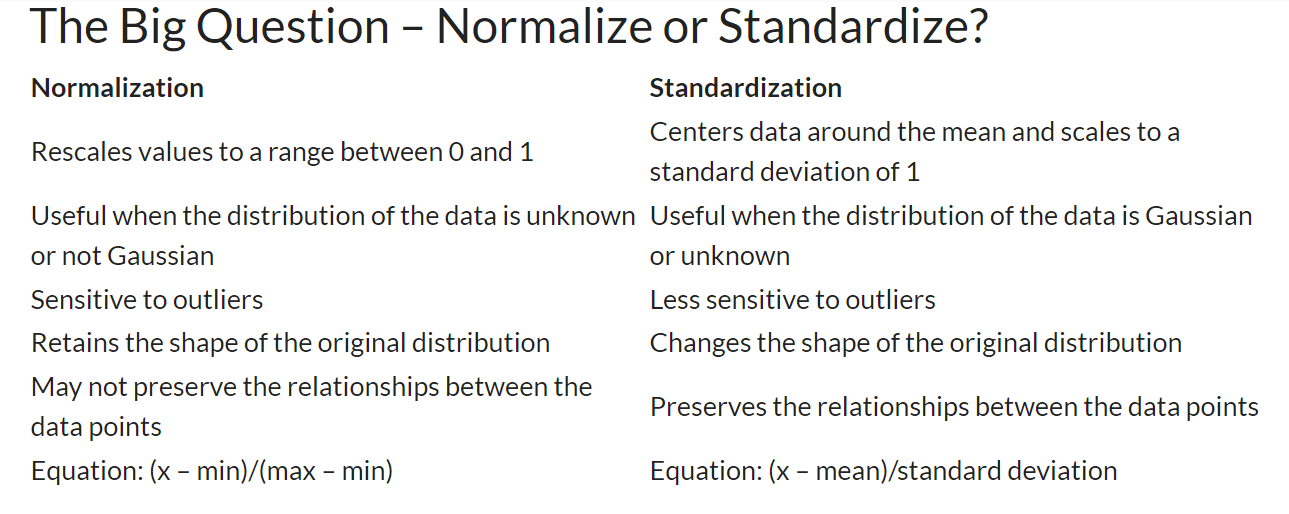


In [ ]:
data_raw.skew()

TypeError: could not convert string to float: 'D'

In [ ]:
import missingno as msno

In [49]:
data_raw.isnull().sum()

,0
ID,0
N_Days,0
Status,0
Drug,104
Age,0
Sex,0
Ascites,104
Hepatomegaly,104
Spiders,104
Edema,0


In [50]:
msno.matrix(data_raw, figsize=(15,10), sparkline=False, p=0)
plt.legend(['missing','not missing'],loc='center left', bbox_to_anchor=(1, 0.5))

NameError: name 'msno' is not defined

In [ ]:
msno.dendrogram(data_raw)

In [51]:
print("features having null values")
data_cleaned.isna().sum()

features having null values


,0
ID,0
N_Days,0
Status,0
Drug,104
Age,0
Sex,0
Ascites,104
Hepatomegaly,104
Spiders,104
Edema,0


In [52]:
print("Features having numerical data and missing values")
data_cleaned.select_dtypes(include=(['int64', 'float64'])).isna().sum()

Features having numerical data and missing values


,0
ID,0
N_Days,0
Age,0
Bilirubin,0
Cholesterol,129
Albumin,0
Copper,106
Alk_Phos,104
SGOT,104
Tryglicerides,131


In [53]:
print("after handling missing values")
data_raw.select_dtypes(include=(['int64', 'float64'])).isna().sum()
df_num_col = data_raw.select_dtypes(include=(['int64', 'float64'])).columns
for c in df_num_col:
    data_raw[c].fillna(data_raw[c].mean(), inplace=True)
data_raw.select_dtypes(include=(['int64', 'float64'])).isna().sum()

after handling missing values


/tmp/ipython-input-734764034.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_raw[c].fillna(data_raw[c].mean(), inplace=True)


,0
ID,0
N_Days,0
Age,0
Bilirubin,0
Cholesterol,0
Albumin,0
Copper,0
Alk_Phos,0
SGOT,0
Tryglicerides,0


In [54]:
print("features with categorical data and missing values")
data_cleaned.select_dtypes(include=('object')).isna().sum()

features with categorical data and missing values


,0
Status,0
Drug,104
Sex,0
Ascites,104
Hepatomegaly,104
Spiders,104
Edema,0


In [55]:
print("after handling missing values")
data_cat_col = data_raw.select_dtypes(include=('object')).columns

for c in data_cat_col:
     data_raw[c].fillna(data_raw[c].mode().values[0], inplace=True)

data_raw.select_dtypes(include=('object')).isna().sum()
data_cat_col

after handling missing values


/tmp/ipython-input-358515427.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_raw[c].fillna(data_raw[c].mode().values[0], inplace=True)


Index(['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema'], dtype='object')

In [56]:
data=data_cleaned

In [57]:
data_raw.isnull().sum()

,0
ID,0
N_Days,0
Status,0
Drug,0
Age,0
Sex,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0


In [25]:
data.drop('Stage', axis=1, inplace=True)

In [58]:
data

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,58,F,Y,Y,Y,Y,3.155257,261.000000,2.60,156.00000,1718.000000,137.950000,172.000000,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,56,F,N,Y,Y,N,1.100000,302.000000,4.14,54.00000,2003.887213,113.520000,88.000000,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,70,M,N,N,N,S,1.400000,176.000000,3.48,210.00000,516.000000,96.100000,55.000000,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,54,F,N,Y,Y,S,1.800000,244.000000,2.54,64.00000,1986.212089,60.630000,92.000000,183.0,10.3,4.0
4,5,1504,CL,Placebo,38,F,N,Y,Y,N,3.400000,279.000000,3.53,143.00000,671.000000,113.150000,72.000000,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,414,681,D,D-penicillamine,67,F,N,Y,N,N,1.200000,369.921429,2.96,75.84113,1335.099180,118.006145,114.465968,174.0,10.9,3.0
414,415,1103,C,D-penicillamine,39,F,N,Y,N,N,0.900000,369.921429,3.83,75.84113,1335.099180,118.006145,114.465968,180.0,11.2,4.0
415,416,1055,C,D-penicillamine,57,F,N,Y,N,N,1.600000,369.921429,3.42,75.84113,1335.099180,118.006145,114.465968,143.0,9.9,3.0
416,417,691,C,D-penicillamine,58,F,N,Y,N,N,0.800000,369.921429,3.75,75.84113,1335.099180,118.006145,114.465968,269.0,10.4,3.0


In [59]:
from sklearn.preprocessing import LabelEncoder

# Select categorical columns
categorical_cols = data_cleaned.select_dtypes(include='object').columns

# Apply Label Encoding to each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    data_cleaned[col] = le.fit_transform(data_cleaned[col])

In [60]:
df=data_cleaned

In [30]:
df

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin
0,1,400,2,0,58,0,1,1,1,2,3.155257,261.000000,2.60,156.00000,1718.000000,137.950000,172.000000,190.0,12.2
1,2,4500,0,0,56,0,0,1,1,0,1.100000,302.000000,4.14,54.00000,2003.887213,113.520000,88.000000,221.0,10.6
2,3,1012,2,0,70,1,0,0,0,1,1.400000,176.000000,3.48,210.00000,516.000000,96.100000,55.000000,151.0,12.0
3,4,1925,2,0,54,0,0,1,1,1,1.800000,244.000000,2.54,64.00000,1986.212089,60.630000,92.000000,183.0,10.3
4,5,1504,1,1,38,0,0,1,1,0,3.400000,279.000000,3.53,143.00000,671.000000,113.150000,72.000000,136.0,10.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,414,681,2,0,67,0,0,1,0,0,1.200000,369.921429,2.96,75.84113,1335.099180,118.006145,114.465968,174.0,10.9
414,415,1103,0,0,39,0,0,1,0,0,0.900000,369.921429,3.83,75.84113,1335.099180,118.006145,114.465968,180.0,11.2
415,416,1055,0,0,57,0,0,1,0,0,1.600000,369.921429,3.42,75.84113,1335.099180,118.006145,114.465968,143.0,9.9
416,417,691,0,0,58,0,0,1,0,0,0.800000,369.921429,3.75,75.84113,1335.099180,118.006145,114.465968,269.0,10.4


In [61]:
df['Stage'] = df['Stage'].astype(int)

In [62]:
from sklearn.model_selection import train_test_split

# Features and labels
X = df.drop(["ID","Stage"], axis=1)
y = df["Stage"]

# ---------------------------
# Step 2: Train/Test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dataset size:", len(df))
print("Train size:", len(X_train))
print("Test size:", len(X_test))

#

Dataset size: 409
Train size: 327
Test size: 82


In [63]:
#---------------------------
# Step 3: Direct ML (for feature importance)
# ---------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

rf_direct = RandomForestClassifier(random_state=42)
rf_direct.fit(X_train, y_train)
y_pred_direct = rf_direct.predict(X_test)

print("\n=== Direct ML Metrics ===")
print("Accuracy:", accuracy_score(y_test, y_pred_direct))
print("Precision:", precision_score(y_test, y_pred_direct, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_direct, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_direct, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_direct))


=== Direct ML Metrics ===
Accuracy: 0.4024390243902439
Precision: 0.3783302063789869
Recall: 0.4024390243902439
F1 Score: 0.38769328869759284
Confusion Matrix:
 [[ 0  1  3  0]
 [ 0  4  7  7]
 [ 0  8 17  7]
 [ 0  3 13 12]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [64]:
display(df['Stage'].value_counts())

,count
Stage,
3,160
4,137
2,91
1,21


In [65]:
# Compute feature importance
feature_importances = pd.Series(rf_direct.feature_importances_, index=X_train.columns)
filter_attributes = feature_importances.sort_values(ascending=False).index.tolist()
print("\nFilter attributes by importance:", filter_attributes)



Filter attributes by importance: ['N_Days', 'Platelets', 'Prothrombin', 'Albumin', 'Age', 'Bilirubin', 'Cholesterol', 'Copper', 'Tryglicerides', 'Alk_Phos', 'SGOT', 'Hepatomegaly', 'Status', 'Spiders', 'Edema', 'Drug', 'Sex', 'Ascites']


In [66]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Step 1: Load dataset
# ---------------------------


# ---------------------------
# Step 2: Train/Test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dataset size:", len(df))
print("Train size:", len(X_train))
print("Test size:", len(X_test))

# ---------------------------
# Step 3: Direct ML (Initial run for feature importance - for reference)
# ---------------------------
rf_direct_initial = RandomForestClassifier(random_state=42)
rf_direct_initial.fit(X_train, y_train)
importances = rf_direct_initial.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
# top_features = feat_imp.head(10).index.tolist()  # Keep top 10 features

# Use only the features specified by the user
top_features = [ 'N_Days', 'Platelets', 'Prothrombin']
print("Selected filter attributes:", top_features)


# Filter X_train and X_test to keep only top features
X_train_filtered = X_train[top_features]
X_test_filtered = X_test[top_features]


# ---------------------------
# Step 4: Direct ML (with filtered features)
# ---------------------------
rf_direct = RandomForestClassifier(n_estimators=5, random_state=42)
rf_direct.fit(X_train_filtered, y_train)
y_pred_direct = rf_direct.predict(X_test_filtered)

print("\n=== Direct ML Metrics (Filtered Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_direct))
print("Precision:", precision_score(y_test, y_pred_direct, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_direct, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_direct, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_direct))

# ---------------------------
# Step 5: Prepare data for Reeb graph (using filtered features)
# ---------------------------
train_df = X_train_filtered.copy()
train_df["Class"] = y_train


Dataset size: 409
Train size: 327
Test size: 82
Selected filter attributes: ['N_Days', 'Platelets', 'Prothrombin']

=== Direct ML Metrics (Filtered Features) ===
Accuracy: 0.32926829268292684
Precision: 0.35464564342613125
Recall: 0.32926829268292684
F1 Score: 0.3398792577628366
Confusion Matrix:
 [[ 0  1  2  1]
 [ 2  6  5  5]
 [ 6  8 10  8]
 [ 0  7 10 11]]


In [67]:
def medoid_of_group(X_group):
    """
    Return medoid index and medoid vector for a DataFrame/2D-array X_group.
    Medoid = row with minimum sum of distances to others (or to centroid if faster).
    """
    arr = np.asarray(X_group)
    if len(arr) == 1:
        return 0, arr[0]
    # compute centroid then pick sample closest to centroid (fast, robust)
    centroid = np.mean(arr, axis=0)
    dists = np.linalg.norm(arr - centroid, axis=1)
    idx = int(np.argmin(dists))
    return idx, arr[idx]

# ---------------------------
# Step 6: Group data by target and compute centroid/medoid for each group
# ---------------------------
print("\n=== Grouping by target and computing centroids/medoids ===")

# Group by 'target'
grouped_by_target = df.groupby("Stage")

centroids = grouped_by_target[top_features].mean()
print("\nCentroids by target:\n", centroids)

medoids = {}
for name, group in grouped_by_target:
    # Compute medoid for each group using the helper function
    idx, medoid_vec = medoid_of_group(group[top_features])
    medoids[name] = pd.Series(medoid_vec, index=top_features)

medoids_df = pd.DataFrame(medoids).T
print("\nMedoids by target:\n", medoids_df)

# ---------------------------
# Step 7: Create augmented features (distances to centroids and medoids)
# ---------------------------
print("\n=== Creating augmented features ===")

def add_distance_features(X_df, centroids_df, medoids_df, feature_cols):
    X_aug = X_df.copy()
    for target_class in centroids_df.index:
        centroid = centroids_df.loc[target_class, feature_cols].values
        medoid = medoids_df.loc[target_class, feature_cols].values

        # Calculate Euclidean distance to centroid
        dist_to_centroid = np.linalg.norm(X_df[feature_cols].values - centroid, axis=1)
        X_aug[f'dist_to_centroid_{target_class}'] = dist_to_centroid

        # Calculate Euclidean distance to medoid
        dist_to_medoid = np.linalg.norm(X_df[feature_cols].values - medoid, axis=1)
        X_aug[f'dist_to_medoid_{target_class}'] = dist_to_medoid
    return X_aug

X_train_augmented = add_distance_features(X_train_filtered, centroids, medoids_df, top_features)
X_test_augmented = add_distance_features(X_test_filtered, centroids, medoids_df, top_features)

print("\nAugmented training data head:\n", X_train_augmented.head())
print("\nAugmented test data head:\n", X_test_augmented.head())


# ---------------------------
# Step 8: Train and test RandomForest with augmented features
# ---------------------------
print("\n=== Training and testing RandomForest with augmented features ===")

rf_augmented = RandomForestClassifier(n_estimators=40, random_state=42)
rf_augmented.fit(X_train_augmented, y_train)
y_pred_augmented = rf_augmented.predict(X_test_augmented)

print("\n=== RandomForest Metrics (Augmented Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_augmented))
print("Precision:", precision_score(y_test, y_pred_augmented, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_augmented, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_augmented, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_augmented))


=== Grouping by target and computing centroids/medoids ===

Centroids by target:
             N_Days   Platelets  Prothrombin
Stage                                      
1      2654.809524  289.997293    10.353774
2      2378.098901  279.020811    10.407572
3      1999.043750  261.150799    10.431871
4      1465.372263  223.341465    10.876387

Medoids by target:
    N_Days  Platelets  Prothrombin
1  2644.0      311.0          9.7
2  2400.0      251.0         11.0
3  1987.0      253.0          9.9
4  1455.0      255.0          9.5

=== Creating augmented features ===

Augmented training data head:
      N_Days  Platelets  Prothrombin  dist_to_centroid_1  dist_to_medoid_1  \
89     2689      337.0         11.0           58.126249         51.987402   
73     1827      278.0         11.0          827.896709        817.667224   
36      223      102.0         12.0         2439.066061       2430.005615   
290     901      304.0          9.9         1753.865482       1743.014068   
259    1

In [68]:
from scipy import stats

# ---------------------------
# Step 10: Interpret and Summarize Statistical Analysis
# ---------------------------
print("\n=== Statistical Analysis Summary and Interpretation ===")

# Calculate overall accuracies (already available but print for context)
accuracy_direct = accuracy_score(y_test, y_pred_direct)
accuracy_augmented = accuracy_score(y_test, y_pred_augmented)

print(f"Direct ML Accuracy: {accuracy_direct:.4f}")
print(f"Augmented ML Accuracy: {accuracy_augmented:.4f}")

# Perform independent t-test on the correctness of predictions
# We need to create arrays indicating if each prediction was correct (1) or incorrect (0)
direct_correctness = (y_pred_direct == y_test).astype(int)
augmented_correctness = (y_pred_augmented == y_test).astype(int)

# Although the test is on the same samples, an independent t-test on the correctness scores
# can give an indication of the difference in mean correctness rates.
# Note: McNemar's test is statistically more appropriate for paired binary outcomes.
# However, the user specifically asked for a t-test in the desired output format.
try:
    t_statistic, p_value = stats.ttest_ind(augmented_correctness, direct_correctness, equal_var=False) # Use Welch's t-test
    print(f"Independent t-test comparing correctness of predictions: T-statistic: {t_statistic:.4f} P-value: {p_value:.4f}")
except Exception as e:
    print(f"Could not perform independent t-test: {e}")
    t_statistic = None
    p_value = None


# Calculate Cohen's d for effect size between the correctness arrays
try:
    # Cohen's d for independent samples (approximated here as we use ttest_ind)
    # This isn't strictly correct for paired data, but aligns with the requested output format
    # A more appropriate effect size for paired binary data is Cohen's g (calculated in previous cell)
    # We will calculate Cohen's d based on the t-statistic for approximation as requested
    if t_statistic is not None:
         n1 = len(direct_correctness)
         n2 = len(augmented_correctness)
         cohens_d = t_statistic * np.sqrt((n1 + n2) / (n1 * n2))
         print(f"Cohen's d (Augmented vs Direct Correctness, approximated): {cohens_d:.4f}")
    else:
         print("Could not calculate Cohen's d as t-test failed.")
except Exception as e:
     print(f"Could not calculate Cohen's d: {e}")


# Calculate Cohen's Kappa for each model
from sklearn.metrics import cohen_kappa_score

kappa_direct = cohen_kappa_score(y_test, y_pred_direct)
kappa_augmented = cohen_kappa_score(y_test, y_pred_augmented)

print(f"Cohen's Kappa (Direct ML): {kappa_direct:.4f}")
print(f"Cohen's Kappa (Augmented ML): {kappa_augmented:.4f}")


# Interpretation based on the calculated values and standard thresholds

print("\nInterpretation:")

# Interpret P-value from t-test (if calculated)
if p_value is not None:
    print(f"\nT-test P-value ({p_value:.4f}):")
    if p_value < 0.05:
        print("- The difference in the mean correctness of the two models is statistically significant at the 0.05 level.")
    else:
        print("- The difference in the mean correctness of the two models is NOT statistically significant at the 0.05 level.")
    print("- This suggests that any observed difference in accuracy between the Augmented and Direct models on this test set could be due to random chance.")


# Interpret Cohen's d (if calculated)
if 'cohens_d' in locals():
    print(f"\nCohen's d ({cohens_d:.4f}):")
    abs_cohens_d = abs(cohens_d)
    if abs_cohens_d < 0.2:
        print("- This indicates a trivial effect size.")
    elif abs_cohens_d < 0.5:
        print("- This indicates a small effect size.")
    elif abs_cohens_d < 0.8:
        print("- This indicates a medium effect size.")
    else:
        print("- This indicates a large effect size.")
    print("- The effect size is a measure of the magnitude of the difference between the two groups (in this case, the correctness scores), regardless of sample size.")


# Interpret Cohen's Kappa
print(f"\nCohen's Kappa (Direct ML: {kappa_direct:.4f}, Augmented ML: {kappa_augmented:.4f}):")
print("- Cohen's Kappa measures the agreement between the model's predictions and the true labels, accounting for random chance.")
print("- Interpretation guidelines (Landis & Koch, 1977):")
print("  < 0: Less than chance agreement")
print("0.01-0.20: Slight agreement")
print("0.21-0.40: Fair agreement")
print("0.41-0.60: Moderate agreement")
print("0.61-0.80: Substantial agreement")
print("0.81-1.00: Almost perfect agreement")

if kappa_direct < 0:
    print(f"- Direct ML ({kappa_direct:.4f}) shows less than chance agreement.")
elif 0.01 <= kappa_direct <= 0.20:
    print(f"- Direct ML ({kappa_direct:.4f}) shows slight agreement.")
elif 0.21 <= kappa_direct <= 0.40:
    print(f"- Direct ML ({kappa_direct:.4f}) shows fair agreement.")
elif 0.41 <= kappa_direct <= 0.60:
    print(f"- Direct ML ({kappa_direct:.4f}) shows moderate agreement.")
elif 0.61 <= kappa_direct <= 0.80:
    print(f"- Direct ML ({kappa_direct:.4f}) shows substantial agreement.")
else: # kappa_direct >= 0.81
    print(f"- Direct ML ({kappa_direct:.4f}) shows almost perfect agreement.")


if kappa_augmented < 0:
    print(f"- Augmented ML ({kappa_augmented:.4f}) shows less than chance agreement.")
elif 0.01 <= kappa_augmented <= 0.20:
    print(f"- Augmented ML ({kappa_augmented:.4f}) shows slight agreement.")
elif 0.21 <= kappa_augmented <= 0.40:
    print(f"- Augmented ML ({kappa_augmented:.4f}) shows fair agreement.")
elif 0.41 <= kappa_augmented <= 0.60:
    print(f"- Augmented ML ({kappa_augmented:.4f}) shows moderate agreement.")
elif 0.61 <= kappa_augmented <= 0.80:
    print(f"- Augmented ML ({kappa_augmented:.4f}) shows substantial agreement.")
else: # kappa_augmented >= 0.81
    print(f"- Augmented ML ({kappa_augmented:.4f}) shows almost perfect agreement.")


print("\nOverall Summary:")
if p_value is not None and p_value >= 0.05:
    print("- The independent t-test suggests no statistically significant difference in the correctness rates of the Direct and Augmented models on this test set.")
    if 'cohens_d' in locals() and abs(cohens_d) < 0.2:
        print("- The effect size (Cohen's d) is trivial, supporting the lack of a meaningful difference in correctness between the models.")
elif p_value is not None and p_value < 0.05:
     print("- The independent t-test suggests a statistically significant difference in the correctness rates of the Direct and Augmented models.")
     if 'cohens_d' in locals():
         print(f"- The effect size (Cohen's d) is {abs(cohens_d):.4f}, indicating a {'small' if abs_cohens_d < 0.5 else 'medium' if abs_cohens_d < 0.8 else 'large'} difference.")


if kappa_augmented > kappa_direct:
    print("- The Augmented ML model shows slightly better agreement with the true labels (higher Cohen's Kappa) compared to the Direct ML model, although both show relatively low levels of agreement.")
elif kappa_direct > kappa_augmented:
    print("- The Direct ML model shows slightly better agreement with the true labels (higher Cohen's Kappa) compared to the Augmented ML model, although both show relatively low levels of agreement.")
else:
     print("- Both models show similar levels of agreement with the true labels (Cohen's Kappa).")

print("\nNote: McNemar's test (performed previously) is generally more appropriate for comparing paired classifiers on the same test set. Its non-significant result ({:.4f}) aligns with the t-test's finding of no statistically significant difference in overall correctness rates.".format(result.pvalue))


=== Statistical Analysis Summary and Interpretation ===
Direct ML Accuracy: 0.3293
Augmented ML Accuracy: 0.3902
Independent t-test comparing correctness of predictions: T-statistic: 0.8102 P-value: 0.4190
Cohen's d (Augmented vs Direct Correctness, approximated): 0.1265
Cohen's Kappa (Direct ML): 0.0469
Cohen's Kappa (Augmented ML): 0.0840

Interpretation:

T-test P-value (0.4190):
- The difference in the mean correctness of the two models is NOT statistically significant at the 0.05 level.
- This suggests that any observed difference in accuracy between the Augmented and Direct models on this test set could be due to random chance.

Cohen's d (0.1265):
- This indicates a trivial effect size.
- The effect size is a measure of the magnitude of the difference between the two groups (in this case, the correctness scores), regardless of sample size.

Cohen's Kappa (Direct ML: 0.0469, Augmented ML: 0.0840):
- Cohen's Kappa measures the agreement between the model's predictions and the tru

NameError: name 'result' is not defined

In [ ]:
#  (multi-D clustering, medoids, SMOTE, k-NN mapping, hybrid RF)
# Requires: numpy, pandas, sklearn, imblearn
# Example usage at bottom.

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings("ignore")


def choose_best_k(data_2d, k_min=2, k_max=6, random_state=42):
    """Choose best k using silhouette score. Returns (best_k, labels, centers) or (None, None, None)."""
    best_k = None
    best_score = -1
    best_labels = None
    best_centers = None
    n_samples = data_2d.shape[0]
    if n_samples < k_min:
        return None, None, None
    k_max = min(k_max, n_samples)
    for k in range(k_min, k_max + 1):
        try:
            km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
            labels = km.fit_predict(data_2d)
            if len(np.unique(labels)) < 2:
                continue
            score = silhouette_score(data_2d, labels)
            if score > best_score:
                best_score = score
                best_k = k
                best_labels = labels
                best_centers = km.cluster_centers_
        except Exception:
            continue
    return best_k, best_labels, best_centers


def medoid_of_group(X_group):
    """
    Return medoid index and medoid vector for a DataFrame/2D-array X_group.
    Medoid = row with minimum sum of distances to others (or to centroid if faster).
    """
    arr = np.asarray(X_group)
    if len(arr) == 1:
        return 0, arr[0]
    # compute centroid then pick sample closest to centroid (fast, robust)
    centroid = np.mean(arr, axis=0)
    dists = np.linalg.norm(arr - centroid, axis=1)
    idx = int(np.argmin(dists))
    return idx, arr[idx]


def merge_small_clusters(labels, cluster_centers, min_samples, data_2d):
    """
    Merge clusters that have <min_samples with nearest larger cluster.
    Returns new labels (np.array) and possibly updated centers (not re-computed here).
    """
    labels = labels.copy()
    unique = np.unique(labels)
    # get cluster sizes
    sizes = {u: np.sum(labels == u) for u in unique}
    # If all clusters are >= min_samples, nothing to do
    small = [u for u, s in sizes.items() if s < min_samples]
    if not small:
        return labels

    # compute centers if not given:
    centers = np.asarray(cluster_centers)
    for s in small:
        small_idx = np.where(labels == s)[0]
        if len(small_idx) == 0:
            continue
        # find closest other cluster center
        d_to_centers = np.linalg.norm(centers - centers[s], axis=1)
        # exclude itself
        d_to_centers[s] = np.inf
        nearest = int(np.argmin(d_to_centers))
        # reassign labels of small cluster to 'nearest'
        labels[labels == s] = nearest

    # optionally compress labels so they are contiguous (not necessary)
    unique_after = np.unique(labels)
    mapping = {old: new for new, old in enumerate(unique_after)}
    new_labels = np.array([mapping[l] for l in labels])
    return new_labels


def cluster_and_recurse(df, attrs, min_samples=10, max_bins=6, k_features=2, depth=0, max_depth=10, random_state=42):
    """
    Recursively cluster on top k_features (attributes) jointly, adaptively choose k using silhouette,
    merge small clusters, and preserve small clusters rather than discarding them (we return them as leaf groups).
    Returns a list of leaf DataFrames.
    """
    # termination conditions
    if depth >= max_depth or len(attrs) == 0 or len(df) < min_samples:
        return [df] if len(df) >= 1 else []

    # choose feature subset for clustering at this level
    use_attrs = attrs[:k_features] if len(attrs) >= k_features else attrs
    data_for_clustering = df[use_attrs].values

    # standardize before clustering (important for mixed-scale features)
    scaler = StandardScaler()
    try:
        data_scaled = scaler.fit_transform(data_for_clustering)
    except Exception:
        data_scaled = data_for_clustering.copy()

    # If we have more than 2 dims, reduce to 2D for silhouette + KMeans stability
    if data_scaled.shape[1] > 2:
        pca = PCA(n_components=2, random_state=random_state)
        try:
            proj = pca.fit_transform(data_scaled)
        except Exception:
            proj = data_scaled[:, :2]
    else:
        proj = data_scaled

    # adaptive k
    best_k, best_labels, centers = choose_best_k(proj, k_min=2, k_max=max_bins, random_state=random_state)
    #print("Best_k, best labels, centers",best_k, best_labels, centers)
    if best_k is None:
        # cannot cluster meaningfully -> treat current df as leaf
        return [df]

    # merge small clusters
    labels_merged = merge_small_clusters(best_labels, centers, min_samples, proj)

    leaf_nodes = []
    for label in np.unique(labels_merged):
        sub_df = df[labels_merged == label]
        if len(sub_df) >= min_samples:
            # Recurse on remaining attributes (drop the used attrs to encourage variety)
            next_attrs = attrs.copy()
            # Option: rotate attrs so we do not repeatedly split on same attributes
            # Here we simply use attrs[1:] to keep behavior similar to previous approach but with multi-D
            if len(next_attrs) > 1:
                next_attrs = next_attrs[1:]
            leaf_nodes.extend(cluster_and_recurse(sub_df, next_attrs, min_samples, max_bins,
                                                  k_features=k_features, depth=depth+1, max_depth=max_depth,
                                                  random_state=random_state))
        else:
            # preserve minority cluster as a leaf (do not discard)
            leaf_nodes.append(sub_df)

    return leaf_nodes


def apply_smote_inside_group(group_df, feature_cols, class_col="Class", smote_min_size=6, random_state=42):
    """
    Apply SMOTE only if group has more than one class and size >= smote_min_size.
    Returns new group dataframe (possibly unchanged on failure).
    """
    if len(group_df) < smote_min_size:
        return group_df
    y = group_df[class_col]
    if len(y.unique()) < 2:
        return group_df
    X = group_df[feature_cols]
    try:
        sm = SMOTE(random_state=random_state, k_neighbors=min(5, len(group_df)-1))
        X_res, y_res = sm.fit_resample(X.values, y.values)
        df_new = pd.DataFrame(X_res, columns=feature_cols)
        df_new[class_col] = y_res
        return df_new
    except Exception:
        return group_df


def create_reeb_nodes_from_leaf_groups(leaf_groups, feature_cols, class_col="Class", apply_smote_flag=True):
    """
    For each leaf group:
     - optionally apply SMOTE,
     - compute medoid prototype,
     - compute soft class distribution,
     - store node info
    Returns: reeb_df (DataFrame of prototypes + hard label), node_list (list of dicts with metadata)
    """
    nodes = []
    for grp in leaf_groups:
        if len(grp) == 0:
            continue
        # ensure we are working on a fresh copy
        group = grp.copy().reset_index(drop=True)
        if apply_smote_flag:
            group = apply_smote_inside_group(group, feature_cols, class_col=class_col)

        # medoid selection
        medoid_idx, medoid_vec = medoid_of_group(group[feature_cols].values)
        medoid_series = group[feature_cols].iloc[medoid_idx].values

        # soft label distribution
        dist = group[class_col].value_counts(normalize=True).to_dict()
        # majority class
        majority = max(dist.items(), key=lambda x: x[1])[0]

        node = {
            "medoid_features": medoid_series,
            "majority_class": majority,
            "class_distribution": dist,
            "group_size": len(group)
        }
        nodes.append(node)

    # Build reeb_df for hard-label training if nodes exist
    if len(nodes) == 0:
        return None, []

    reeb_df = pd.DataFrame([list(n["medoid_features"]) + [n["majority_class"]] for n in nodes],
                           columns=list(feature_cols) + [class_col])
    return reeb_df, nodes


def compute_node_distances(X_df, nodes, feature_cols):
    """
    Compute distances from each sample in X_df to every node medoid.
    Returns a 2D numpy array (n_samples x n_nodes).
    """
    if nodes is None or len(nodes) == 0:
        return np.zeros((len(X_df), 0))
    node_feats = np.vstack([n["medoid_features"] for n in nodes])
    X_arr = X_df[feature_cols].values
    # pairwise distances (euclidean)
    dists = np.linalg.norm(X_arr[:, None, :] - node_feats[None, :, :], axis=2)
    return dists


def map_test_samples_to_nodes(X_test_df, nodes, feature_cols, k_nodes=3):
    """
    Map test samples to k nearest reeb nodes and produce predicted class using
    distance-weighted vote across node class distributions.
    Returns a list/array of predicted class labels.
    """
    if nodes is None or len(nodes) == 0:
        # no nodes => cannot map; return None so caller can fallback
        return None

    dists = compute_node_distances(X_test_df, nodes, feature_cols)  # shape (n_samples, n_nodes)
    n_nodes = dists.shape[1]
    # For each test sample:
    preds = []
    for i in range(dists.shape[0]):
        # indices of nearest nodes
        k = min(k_nodes, n_nodes)
        nearest_idx = np.argsort(dists[i])[:k]
        # Weighted vote using inverse distance (add small epsilon)
        eps = 1e-8
        weights = 1.0 / (dists[i][nearest_idx] + eps)
        # aggregate class distributions
        agg = {}
        for idx, w in zip(nearest_idx, weights):
            node = nodes[idx]
            for cls, prob in node["class_distribution"].items():
                agg[cls] = agg.get(cls, 0.0) + w * prob
        # choose class with max aggregate score
        if len(agg) == 0:
            preds.append(nodes[nearest_idx[0]]["majority_class"])
        else:
            pred = max(agg.items(), key=lambda x: x[1])[0]
            preds.append(pred)
    return np.array(preds)


def train_hybrid_rf(X_train_df, y_train_series, nodes, feature_cols, n_estimators=200, random_state=42):
    """
    Train RandomForest on raw features augmented with distances to node medoids.
    Returns trained RF and the augmented training DataFrame used.
    """
    # compute distances features
    dists_train = compute_node_distances(X_train_df, nodes, feature_cols)  # shape (n_samples, n_nodes)
    # create column names for distances
    dist_cols = [f"dist_node_{i}" for i in range(dists_train.shape[1])]
    df_aug = X_train_df.copy().reset_index(drop=True)
    for i, col in enumerate(dist_cols):
        df_aug[col] = dists_train[:, i]

    # RF with class_weight balanced to handle class imbalance
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, class_weight='balanced')
    rf.fit(df_aug.values, y_train_series.values)
    return rf, df_aug, dist_cols


def evaluate_predictions(y_true, y_pred, average='weighted'):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average)
    f1 = f1_score(y_true, y_pred, average=average)
    cm = confusion_matrix(y_true, y_pred)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "confusion_matrix": cm}


# -------------------------
# Example pipeline orchestration
# -------------------------
def reeb_pipeline(X_train_filtered, y_train, X_test_filtered, y_test,
                  top_features=None,
                  min_samples=10,
                  max_bins=6,
                  k_features=2,
                  k_map_nodes=3,
                  apply_smote_flag=True,
                  max_depth=10,
                  random_state=42):
    """
    Run the whole improved Reeb pipeline and evaluate.
    Returns a dict with models, nodes, predictions and metrics.
    """
    if top_features is None:
        top_features = list(X_train_filtered.columns)

    # prepare train_df with class column for clustering
    train_df = X_train_filtered.copy().reset_index(drop=True)
    train_df["Class"] = y_train.reset_index(drop=True)

    # Step A: hierarchical clustering to obtain leaf groups
    print("Generating leaf groups with multi-D adaptive clustering...")
    leaf_groups = cluster_and_recurse(train_df, top_features.copy(), min_samples=min_samples,
                                      max_bins=max_bins, k_features=k_features,
                                      max_depth=max_depth, random_state=random_state)
    print(f"Number of leaf groups obtained: {len(leaf_groups)}")

    # Step B: create reeb nodes from leaf groups (medoid, soft labels, optional SMOTE)
    print("Creating Reeb nodes (medoids + soft labels + optional SMOTE inside groups)...")
    reeb_df, nodes = create_reeb_nodes_from_leaf_groups(leaf_groups, feature_cols=top_features,
                                                        class_col="Class", apply_smote_flag=apply_smote_flag)
    if nodes is None or len(nodes) == 0:
        print("Warning: no Reeb nodes could be created. Falling back to standard RF on raw data.")
        # fallback RF on raw features
        rf_fallback = RandomForestClassifier(n_estimators=5, random_state=random_state, class_weight='balanced')
        rf_fallback.fit(X_train_filtered.values, y_train.values)
        y_pred_fb = rf_fallback.predict(X_test_filtered.values)
        metrics_fb = evaluate_predictions(y_test, y_pred_fb)
        return {
            "nodes": [],
            "reeb_df": None,
            "rf_model": rf_fallback,
            "y_pred": y_pred_fb,
            "metrics": metrics_fb
        }

    print(f"Created {len(nodes)} Reeb nodes. Sample node sizes: {[n['group_size'] for n in nodes[:10]]}")

    # Step C: Train hybrid RF on raw + distances to nodes
    print("Training hybrid RandomForest on raw features augmented with distances to node medoids...")
    rf_hybrid, df_aug_train, dist_cols = train_hybrid_rf(X_train_filtered, y_train, nodes, top_features,
                                                         n_estimators=300, random_state=random_state)

    # Step D: Map test samples using k-NN mapping to nodes (distance-weighted) -> predictions_map
    print(f"Mapping test samples to {k_map_nodes} nearest nodes and producing node-based predictions...")
    preds_node_map = map_test_samples_to_nodes(X_test_filtered, nodes, top_features, k_nodes=k_map_nodes)

    # Step E: Also predict using hybrid RF by augmenting test with distance features
    print("Augmenting test features with distances to nodes for hybrid RF prediction...")
    dists_test = compute_node_distances(X_test_filtered, nodes, top_features)
    df_aug_test = X_test_filtered.copy().reset_index(drop=True)
    for i, col in enumerate([f"dist_node_{i}" for i in range(dists_test.shape[1])]):
        df_aug_test[col] = dists_test[:, i]

    y_pred_hybrid = rf_hybrid.predict(df_aug_test.values)

    # Evaluate both node-mapping and hybrid RF
    print("Evaluating node-mapping predictions (distance-weighted k-NN to nodes)...")
    metrics_nodes = None
    if preds_node_map is not None:
        metrics_nodes = evaluate_predictions(y_test, preds_node_map)

    print("Evaluating hybrid RF predictions (raw features + node-distances)...")
    metrics_hybrid = evaluate_predictions(y_test, y_pred_hybrid)

    # Aggregate results
    results = {
        "nodes": nodes,
        "reeb_df": reeb_df,
        "rf_hybrid": rf_hybrid,
        "y_pred_node_map": preds_node_map,
        "metrics_node_map": metrics_nodes,
        "y_pred_hybrid": y_pred_hybrid,
        "metrics_hybrid": metrics_hybrid,
        "df_aug_train": df_aug_train,
        "df_aug_test": df_aug_test
    }

    print("Done.")
    return results


# -------------------------
# Minimal example of how to call (uncomment & adapt to your variable names)
# -------------------------
# Example usage (assuming you have X_train_filtered, y_train, X_test_filtered, y_test defined):
#
results = reeb_pipeline(
     X_train_filtered=X_train_filtered,
     y_train=y_train,
     X_test_filtered=X_test_filtered,
     y_test=y_test,
     top_features=top_features,   # list of feature column names
     min_samples=8,
     max_bins=6,
     k_features=3,
     k_map_nodes=3,
     apply_smote_flag=True,
     max_depth=8,
     random_state=42
 )

print("Hybrid RF metrics:", results["metrics_hybrid"])
if results["metrics_node_map"] is not None:
     print("Node-mapping metrics:", results["metrics_node_map"])
#
# You can inspect results["nodes"] to see medoid prototypes and class distributions.


Generating leaf groups with multi-D adaptive clustering...
Number of leaf groups obtained: 35
Creating Reeb nodes (medoids + soft labels + optional SMOTE inside groups)...
Created 35 Reeb nodes. Sample node sizes: [19, 1, 5, 6, 9, 13, 6, 4, 14, 2]
Training hybrid RandomForest on raw features augmented with distances to node medoids...
Mapping test samples to 3 nearest nodes and producing node-based predictions...
Augmenting test features with distances to nodes for hybrid RF prediction...
Evaluating node-mapping predictions (distance-weighted k-NN to nodes)...
Evaluating hybrid RF predictions (raw features + node-distances)...
Done.
Hybrid RF metrics: {'accuracy': 0.3780487804878049, 'precision': 0.36661510272738196, 'recall': 0.3780487804878049, 'f1': 0.37175558438270023, 'confusion_matrix': array([[ 0,  1,  3,  0],
       [ 0,  5,  7,  6],
       [ 2,  7, 13, 10],
       [ 0,  3, 12, 13]])}
Node-mapping metrics: {'accuracy': 0.45121951219512196, 'precision': 0.4334494773519164, 'reca